In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("code-vs-text.csv")
data.head()

,line,label,source
0,<View>,1,stackoverflow_2020
1,"Looking at further documentation, it seems tha...",0,stackoverflow_2020
2,org.mockito.exceptions.misusing.WrongTypeOfRet...,1,stackoverflow_2020
3,"let randomArray = [1,2,4,591,392,391,2,5,10,2,...",1,stackoverflow_2020
4,c.c:3:19: note: each undeclared identifier is ...,1,stackoverflow_2020


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52270 entries, 0 to 52269
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   line    52266 non-null  object
 1   label   52270 non-null  int64 
 2   source  52270 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [4]:
data.describe()

,label
count,52270.000000
mean,0.477138
std,0.499482
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [5]:
data.isnull().sum()

line      4
label     0
source    0
dtype: int64

In [6]:
#Deleting rows foe all the 4 instances of null values in text column to clean the data.
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52266 entries, 0 to 52269
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   line    52266 non-null  object
 1   label   52266 non-null  int64 
 2   source  52266 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


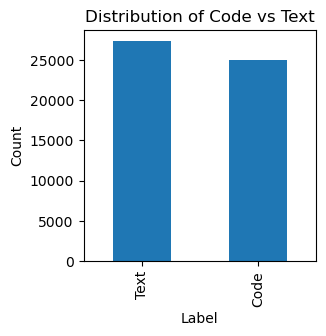

In [7]:
plt.figure(figsize=(3,3))
data["label_name"] = data.label.map({0:"Text",1:"Code"})
data.label_name.value_counts().plot.bar()
plt.title("Distribution of Code vs Text")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

From above bar chart of count of text vs code , both the classes looks balanced.

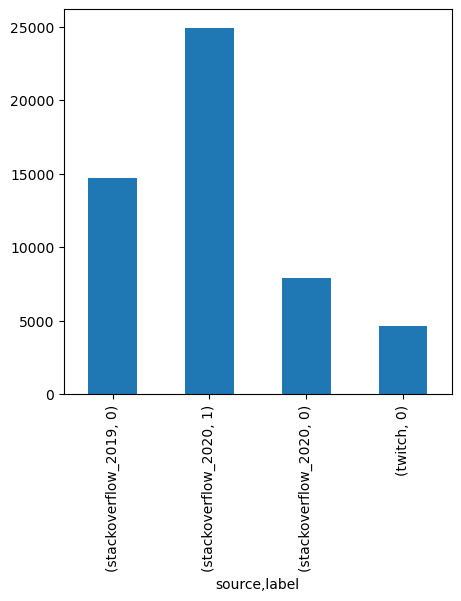

In [8]:
plt.figure(figsize=(5,5))
data.groupby("source")["label"].value_counts().plot.bar()

plt.show()

In [9]:
data["line_length"]= data.line.str.len()
#data["line_length"].head()

data[["line","line_length"]].head()

,line,line_length
0,<View>,6
1,"Looking at further documentation, it seems tha...",117
2,org.mockito.exceptions.misusing.WrongTypeOfRet...,56
3,"let randomArray = [1,2,4,591,392,391,2,5,10,2,...",59
4,c.c:3:19: note: each undeclared identifier is ...,96


In [10]:
data['line_length'].describe()

count    52266.000000
mean        59.531741
std         85.952399
min          1.000000
25%         17.000000
50%         34.000000
75%         72.000000
max       9082.000000
Name: line_length, dtype: float64

In [11]:
data.groupby("label_name")["line_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Code,24938.0,38.975660,47.750157,3.0,16.0,29.0,50.0,3062.0
Text,27328.0,78.290069,106.356024,1.0,18.0,46.0,107.0,9082.0


##Insights:
Text lines means are generally longer because they contain full natural language sentences, while code lines are usually concise instructions.


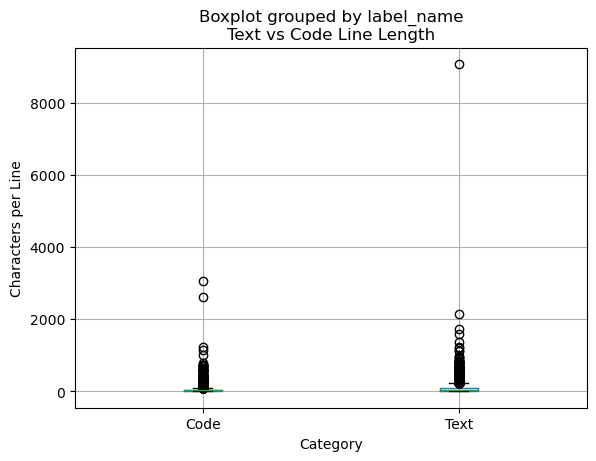

In [12]:
data.boxplot(column="line_length", by="label_name")

plt.title("Text vs Code Line Length")
plt.xlabel("Category")
plt.ylabel("Characters per Line")

plt.show()

The median line length for text is higher than code, indicating that typical text lines contain more characters than code lines.

Outliers:Some extremely long lines exist, likely due to long code expressions or detailed textual explanations.
Stnd Dev: Text lines show greater variability in length because human language varies widely in sentence size, while code tends to follow more consistent formatting patterns

What Boxplot showing ? - Code line lengths are more tightly distributed, while text line lengths vary significantly.

Hence we can say that -The difference in line length distribution between code and text suggests that line length could be an effective feature for building a classification model that distinguishes programming code from natural language.

In [13]:
data["symbol_count"] = data["line"].apply(
    lambda
        x:sum(char in "{}();<>/*[]+-" for char in x
    )
)

In [14]:
data[["line", 'symbol_count']].head(10)

,line,symbol_count
0,<View>,2
1,"Looking at further documentation, it seems tha...",0
2,org.mockito.exceptions.misusing.WrongTypeOfRet...,0
3,"let randomArray = [1,2,4,591,392,391,2,5,10,2,...",3
4,c.c:3:19: note: each undeclared identifier is ...,0
5,std::vector<char> my_buf (buf_size);,5
6,Task Manager:\nPerformance: Virtualization is ...,0
7,P OMEGALUL S T N OMEGALUL T,0
8,libgpuarray 0.7.6 ...,0
9,"[ 3 ] Use ""require"" with a dynamic lookup",2


In [15]:
data.groupby("label_name")["symbol_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Code,24938.0,3.120178,15.316965,0.0,1.0,2.0,4.0,2108.0
Text,27328.0,0.587602,2.445844,0.0,0.0,0.0,0.0,159.0


<Axes: title={'center': 'symbol_count'}, xlabel='label_name'>

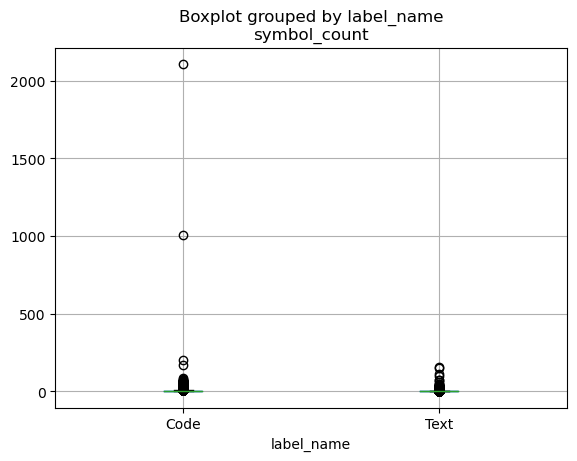

In [16]:
data.boxplot(column="symbol_count", by="label_name")

Code lines generally contain more special characters than text lines.

Outliers:Some code lines contain many symbols depending on complexity.

Symbol count therefore appears to be a useful feature for distinguishing code from natural language text

<Axes: xlabel='symbol_count', ylabel='Count'>

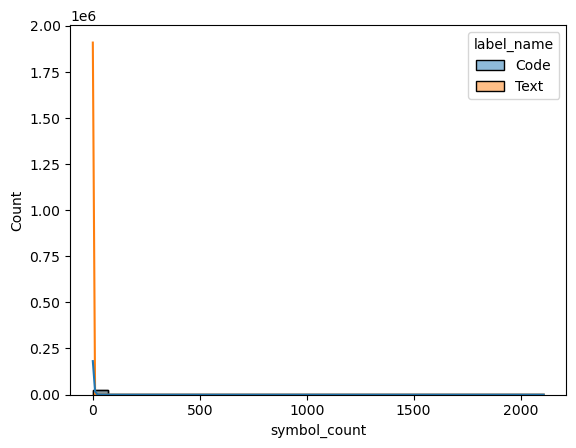

In [17]:
sns.histplot(data=data, hue="label_name", x="symbol_count", bins=30, kde=True)

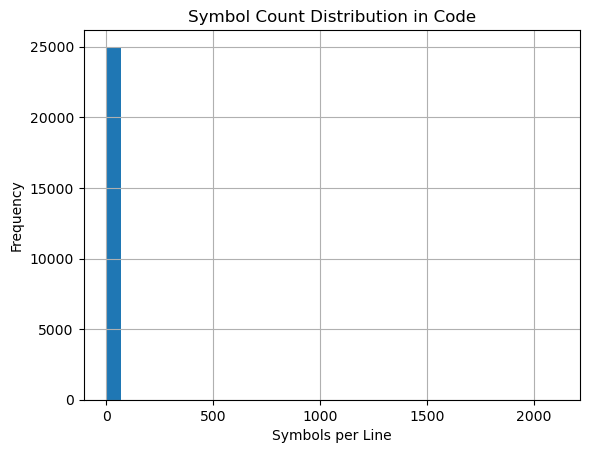

In [18]:
data[data["label_name"]=="Code"]["symbol_count"].hist(bins=30)

plt.title("Symbol Count Distribution in Code")
plt.xlabel("Symbols per Line")
plt.ylabel("Frequency")

plt.show()

This is called a right-skewed distribution.
Most code lines contain only a small number of special characters, while a small number of lines contain extremely high symbol counts.

# Top words in text vs code (NLP insight)

In [19]:
data.head()

,line,label,source,label_name,line_length,symbol_count
0,<View>,1,stackoverflow_2020,Code,6,2
1,"Looking at further documentation, it seems tha...",0,stackoverflow_2020,Text,117,0
2,org.mockito.exceptions.misusing.WrongTypeOfRet...,1,stackoverflow_2020,Code,56,0
3,"let randomArray = [1,2,4,591,392,391,2,5,10,2,...",1,stackoverflow_2020,Code,59,3
4,c.c:3:19: note: each undeclared identifier is ...,1,stackoverflow_2020,Code,96,0


In [26]:
text_lines = data[data["label_name"]=="Text"]["line"]
code_lines = data[data["label_name"]=='Code']['line']

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

In [28]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)
code_matrix = vectorizer.fit_transform(code_lines)
code_words = vectorizer.get_feature_names_out()
code_word_count = code_matrix.sum(axis=0).A1

In [29]:
top_word_codes = pd.DataFrame({"Top code words":code_words,"count":code_word_count}).sort_values(by='count', ascending=False).reset_index()
top_word_codes.drop(columns='index', inplace=True)
top_word_codes

,Top code words,count
0,java,961
1,return,906
2,int,816
3,org,715
4,class,662
5,public,640
6,const,561
7,app,520
8,data,516
9,string,492


-- Code lines are dominated by programming language syntax and keywords such as return, int, class, and public, which are essential components of programming languages

--The dataset contains code from multiple programming ecosystems, including Java, C/C++, JavaScript, and React-based web development.

--Code lines frequently contain structural elements such as imports, variable declarations, and class definitions.

In [30]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)
line_matrix = vectorizer.fit_transform(text_lines)
line_words = vectorizer.get_feature_names_out()
line_word_count = line_matrix.sum(axis=0).A1

In [31]:
top_word = pd.DataFrame({'Top text words':line_words,"count":line_word_count}).sort_values(by='count', ascending=False).reset_index()
top_word.drop(columns='index',inplace=True)
top_word

,Top text words,count
0,code,1994
1,like,1566
2,error,1386
3,using,1372
4,following,1119
5,app,1052
6,use,955
7,way,938
8,tried,904
9,problem,878


--Text lines mainly consist of problem descriptions, debugging discussions, and explanations typical of programming forums.

--Code lines contain technical syntax and programming constructs, while text lines contain natural language expressions describing problems, solutions, and usage examples.

--Some technical terms appear in both categories because they are used both in code implementation and in textual explanations.